In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
housing_data = pd.read_csv("../data/train.csv")
housing_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1. Exploration des données (EDA)

### 1.1 Dimensions du dataset

In [4]:
rows, cols = housing_data.shape
print(f"Lignes : {rows}")
print(f"Colonnes : {cols}")

Lignes : 1460
Colonnes : 81


### 1.2 Types des colonnes (dtypes)

In [5]:
numeric_cols = housing_data.select_dtypes(include="number").columns.tolist()
categorical_cols = housing_data.select_dtypes(include="object").columns.tolist()

print(f"Colonnes numériques ({len(numeric_cols)}) : {numeric_cols}")
print(f"Colonnes catégorielles ({len(categorical_cols)}) : {categorical_cols}")

Colonnes numériques (38) : ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
Colonnes catégorielles (43) : ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functi

### 1.3 Statistiques descriptives (describe)

In [6]:
housing_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### 1.4 Distribution de la variable cible — SalePrice

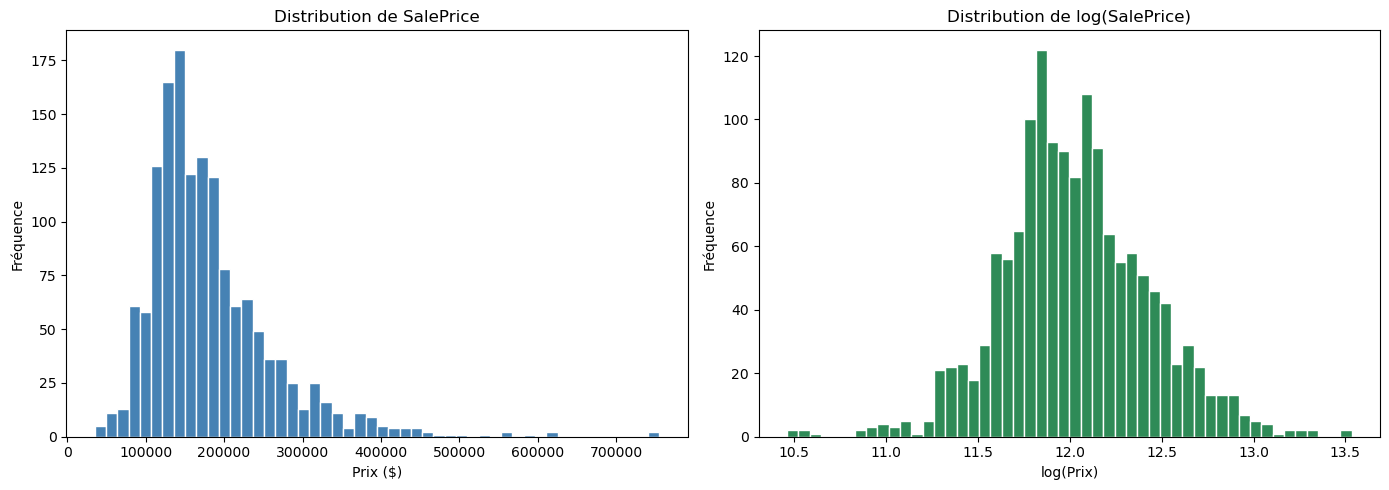

Skewness   : 1.8829  (> 0 = asymétrie à droite)
Kurtosis   : 6.5363  (> 3 = queues lourdes)
Skewness log-transformé : 0.1213


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution originale
axes[0].hist(housing_data["SalePrice"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution de SalePrice")
axes[0].set_xlabel("Prix ($)")
axes[0].set_ylabel("Fréquence")

# Distribution log-transformée
axes[1].hist(np.log1p(housing_data["SalePrice"]), bins=50, color="seagreen", edgecolor="white")
axes[1].set_title("Distribution de log(SalePrice)")
axes[1].set_xlabel("log(Prix)")
axes[1].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

skewness = housing_data["SalePrice"].skew()
kurtosis = housing_data["SalePrice"].kurt()
print(f"Skewness   : {skewness:.4f}  (> 0 = asymétrie à droite)")
print(f"Kurtosis   : {kurtosis:.4f}  (> 3 = queues lourdes)")
print(f"Skewness log-transformé : {np.log1p(housing_data['SalePrice']).skew():.4f}")

### 1.5 Valeurs manquantes

              NaN count  Pourcentage
PoolQC             1453        99.52
MiscFeature        1406        96.30
Alley              1369        93.77
Fence              1179        80.75
MasVnrType          872        59.73
FireplaceQu         690        47.26
LotFrontage         259        17.74
GarageType           81         5.55
GarageYrBlt          81         5.55
GarageFinish         81         5.55
GarageQual           81         5.55
GarageCond           81         5.55
BsmtExposure         38         2.60
BsmtFinType2         38         2.60
BsmtQual             37         2.53
BsmtCond             37         2.53
BsmtFinType1         37         2.53
MasVnrArea            8         0.55
Electrical            1         0.07


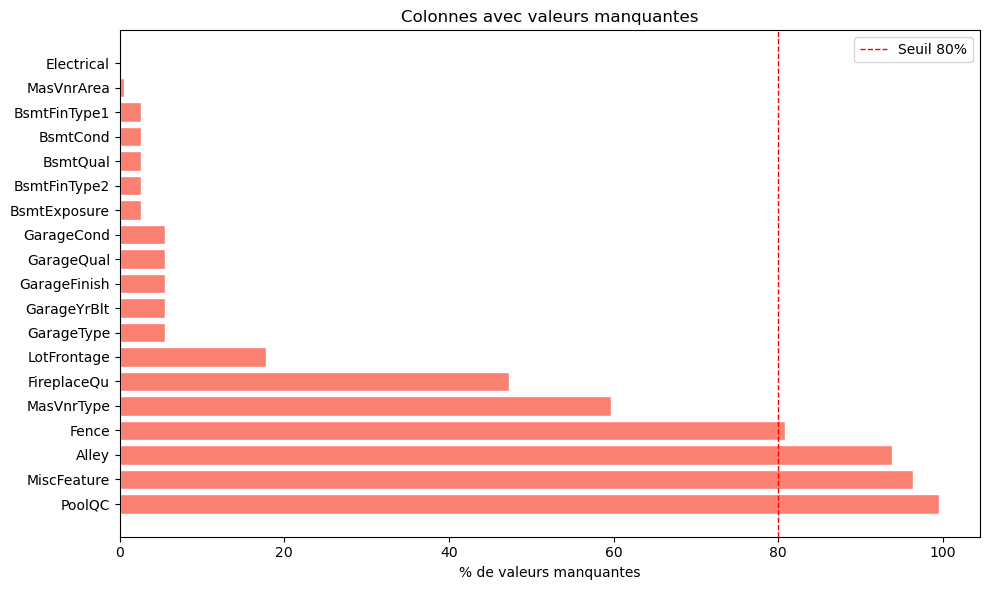

In [8]:
missing = (
    housing_data.isnull().sum()
    .pipe(lambda s: s[s > 0])
    .sort_values(ascending=False)
    .to_frame(name="NaN count")
    .assign(Pourcentage=lambda df: (df["NaN count"] / len(housing_data) * 100).round(2))
)
print(missing.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(missing.index, missing["Pourcentage"], color="salmon", edgecolor="white")
ax.axvline(80, color="red", linestyle="--", linewidth=1, label="Seuil 80%")
ax.set_xlabel("% de valeurs manquantes")
ax.set_title("Colonnes avec valeurs manquantes")
ax.legend()
plt.tight_layout()
plt.show()

### 1.6 Heatmap des corrélations

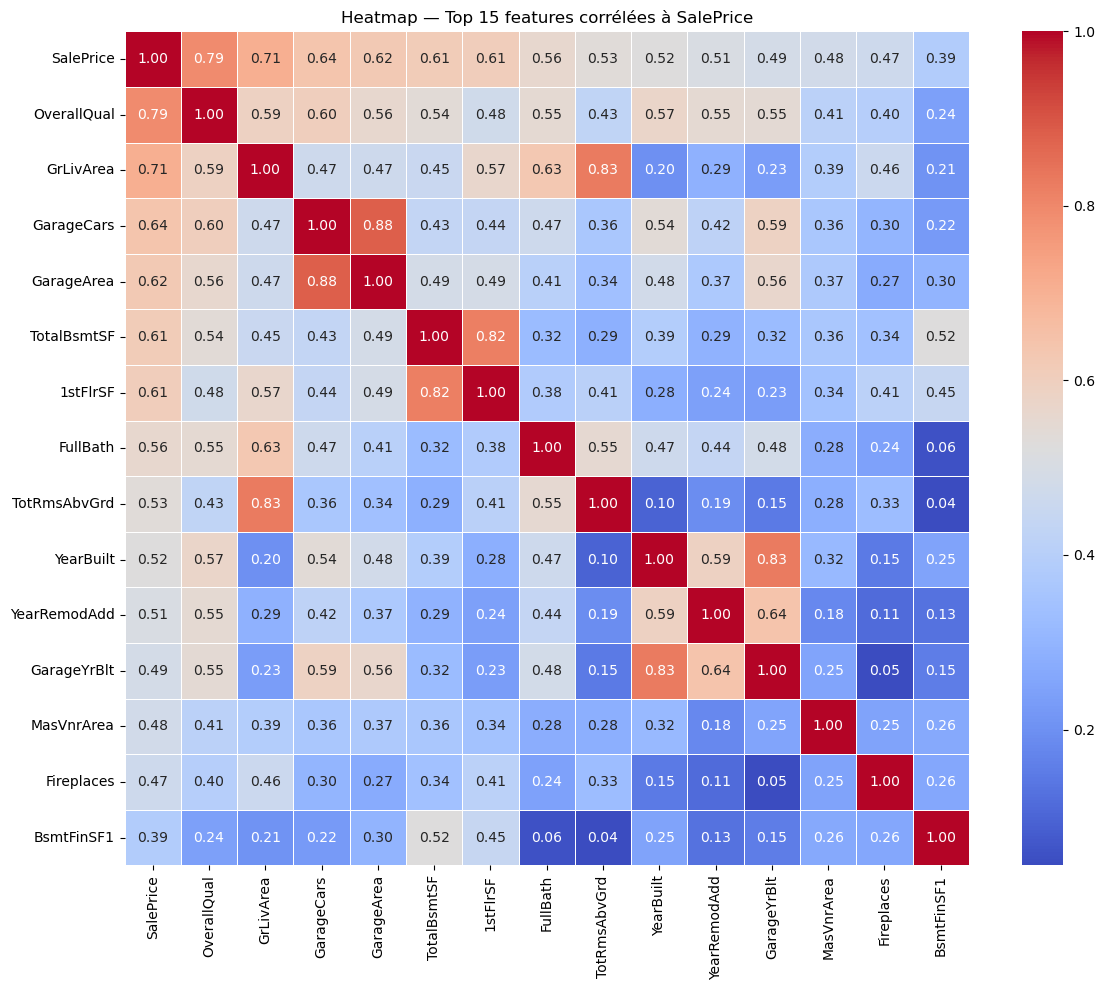

In [9]:
top_corr_cols = housing_data.select_dtypes(include="number").corr()["SalePrice"].abs().nlargest(15).index

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    housing_data[top_corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    ax=ax
)
ax.set_title("Heatmap — Top 15 features corrélées à SalePrice")
plt.tight_layout()
plt.show()

### 1.7 Top features corrélées à SalePrice

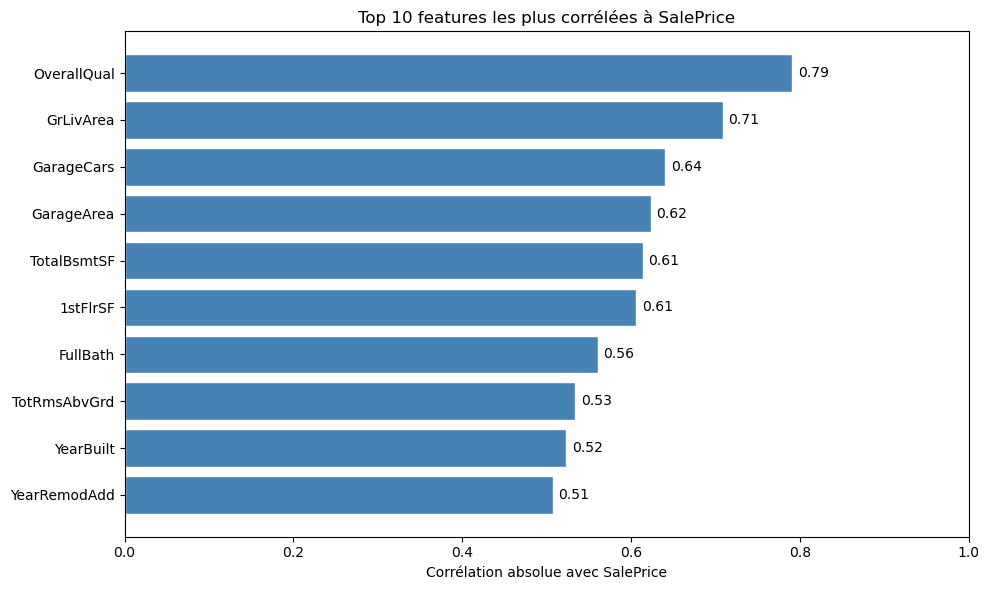

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101


In [10]:
correlations = (
    housing_data.select_dtypes(include="number")
    .corr()["SalePrice"]
    .drop("SalePrice")
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(correlations.index[::-1], correlations.values[::-1], color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt="%.2f", padding=4)
ax.set_xlabel("Corrélation absolue avec SalePrice")
ax.set_title("Top 10 features les plus corrélées à SalePrice")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

print(correlations.to_string())

## 2. Nettoyage des données

### 2.1 Suppression des colonnes inutiles et trop incomplètes (> 80% NaN)

In [11]:
df = housing_data.copy()

# Id n'a aucune valeur prédictive
df.drop(columns=["Id"], inplace=True)

# MSSubClass est un code catégoriel, pas une valeur numérique continue
df["MSSubClass"] = df["MSSubClass"].astype(str)

# Supprimer les colonnes avec plus de 80% de NaN
threshold = 0.80 * len(df)
cols_to_drop = [col for col in df.columns if df[col].isnull().sum() > threshold]
df.drop(columns=cols_to_drop, inplace=True)

print(f"Colonnes supprimées (> 80% NaN) : {cols_to_drop}")
print(f"Shape après suppression : {df.shape}")

Colonnes supprimées (> 80% NaN) : ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
Shape après suppression : (1460, 76)


### 2.2 Imputation des valeurs manquantes

In [12]:
# NaN = absence de la feature (ex: pas de garage, pas de sous-sol) → "None" / 0
cat_none_cols = [
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "FireplaceQu", "MasVnrType"
]
for col in cat_none_cols:
    if col in df.columns:
        df[col] = df[col].fillna("None")

num_zero_cols = [
    "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath", "GarageYrBlt", "GarageArea", "GarageCars"
]
for col in num_zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# LotFrontage : médiane par quartier (Neighborhood) — plus précis que la médiane globale
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

# Electrical : 1 seul NaN → on prend la valeur la plus fréquente
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

remaining_nan = df.isnull().sum().sum()
print(f"NaN restants après imputation : {remaining_nan}")

NaN restants après imputation : 0


### 2.3 Détection et traitement des outliers

Outliers détectés (GrLivArea > 4000 & prix bas) : 2 lignes


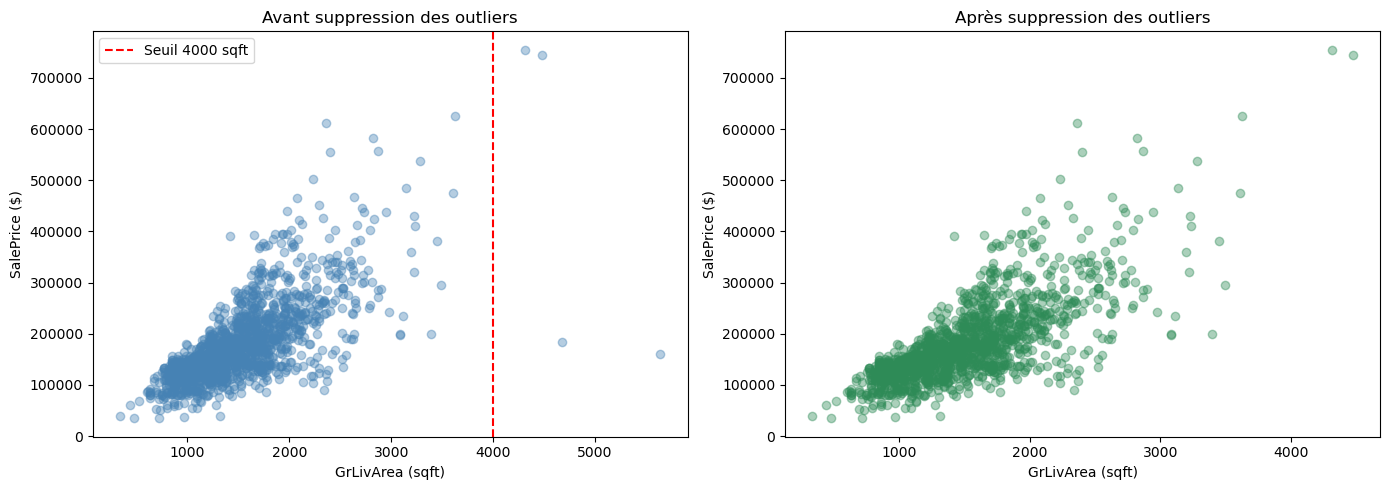

Shape final après nettoyage : (1458, 76)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["GrLivArea"], df["SalePrice"], alpha=0.4, color="steelblue")
axes[0].axvline(4000, color="red", linestyle="--", linewidth=1.5, label="Seuil 4000 sqft")
axes[0].set_xlabel("GrLivArea (sqft)")
axes[0].set_ylabel("SalePrice ($)")
axes[0].set_title("Avant suppression des outliers")
axes[0].legend()

# 2 maisons > 4000 sqft vendues anormalement bas → outliers connus de ce dataset
outliers_mask = (df["GrLivArea"] > 4000) & (df["SalePrice"] < 300_000)
print(f"Outliers détectés (GrLivArea > 4000 & prix bas) : {outliers_mask.sum()} lignes")
df = df[~outliers_mask].reset_index(drop=True)

axes[1].scatter(df["GrLivArea"], df["SalePrice"], alpha=0.4, color="seagreen")
axes[1].set_xlabel("GrLivArea (sqft)")
axes[1].set_ylabel("SalePrice ($)")
axes[1].set_title("Après suppression des outliers")

plt.tight_layout()
plt.show()

print(f"Shape final après nettoyage : {df.shape}")

### 2.4 Encodage des variables catégorielles

In [14]:
# Transformation log de SalePrice pour corriger la distribution asymétrique
df["SalePrice"] = np.log1p(df["SalePrice"])

# One-hot encoding — get_dummies appelé une seule fois
df_encoded = pd.get_dummies(df, drop_first=True)
bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f"Shape avant encodage : {df.shape}")
print(f"Shape après encodage : {df_encoded.shape}")
df_encoded.head()

Shape avant encodage : (1458, 76)
Shape après encodage : (1458, 259)


,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,65.0,8450,7,5,2003,2003,196.0,706,0,150,...,0,0,0,0,1,0,0,0,1,0
1,80.0,9600,6,8,1976,1976,0.0,978,0,284,...,0,0,0,0,1,0,0,0,1,0
2,68.0,11250,7,5,2001,2002,162.0,486,0,434,...,0,0,0,0,1,0,0,0,1,0
3,60.0,9550,7,5,1915,1970,0.0,216,0,540,...,0,0,0,0,1,0,0,0,0,0
4,84.0,14260,8,5,2000,2000,350.0,655,0,490,...,0,0,0,0,1,0,0,0,1,0


## 3. Feature Engineering

### 3.1 Création de nouvelles features

In [15]:
new_cols = pd.DataFrame({
    "TotalSF":      df_encoded["GrLivArea"] + df_encoded["TotalBsmtSF"],
    "HouseAge":     df_encoded["YrSold"] - df_encoded["YearBuilt"],
    "RemodAge":     df_encoded["YrSold"] - df_encoded["YearRemodAdd"],
    "TotalBath":    (df_encoded["FullBath"] + 0.5 * df_encoded["HalfBath"] +
                     df_encoded["BsmtFullBath"] + 0.5 * df_encoded["BsmtHalfBath"]),
    "HasGarage":    (df_encoded["GarageArea"] > 0).astype(int),
    "HasFireplace": (df_encoded["Fireplaces"] > 0).astype(int),
})
df_encoded = pd.concat([df_encoded, new_cols], axis=1)

new_features = list(new_cols.columns)
print("Nouvelles features créées :")
df_encoded[new_features].describe().round(2)

Nouvelles features créées :


,TotalSF,HouseAge,RemodAge,TotalBath,HasGarage,HasFireplace
count,1458.00,1458.00,1458.00,1458.00,1458.00,1458.00
mean,2563.00,36.60,22.98,2.21,0.94,0.53
std,776.19,30.24,20.64,0.78,0.23,0.50
min,334.00,0.00,0.00,1.00,0.00,0.00
25%,2014.00,8.00,4.00,2.00,1.00,0.00
50%,2476.50,35.00,14.00,2.00,1.00,1.00
75%,3005.50,54.00,41.00,2.50,1.00,1.00
max,6872.00,136.00,60.00,6.00,1.00,1.00


### 3.2 Sélection des features importantes

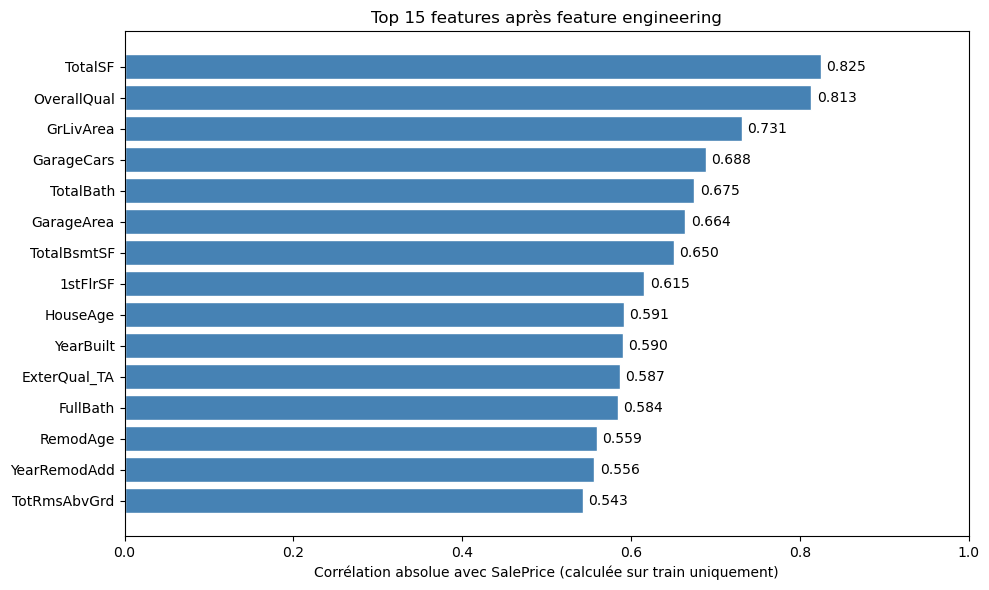

Features sélectionnées (|corr| > 0.1, sur train) : 138
X shape : (1458, 138)  |  y shape : (1458,)


In [16]:
from sklearn.model_selection import train_test_split

# Split préliminaire pour calculer les corrélations sur train seulement
# (évite la fuite de données : le test set ne doit pas influencer la sélection des features)
_X = df_encoded.drop(columns=["SalePrice"])
_y = df_encoded["SalePrice"]
_X_train, _, _y_train, _ = train_test_split(_X, _y, test_size=0.2, random_state=42)

train_corr_df = pd.concat([_X_train, _y_train], axis=1)
correlations = (
    train_corr_df.corr()["SalePrice"]
    .drop("SalePrice")
    .abs()
    .sort_values(ascending=False)
)

top_15 = correlations.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_15.index[::-1], top_15.values[::-1], color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=4)
ax.set_xlabel("Corrélation absolue avec SalePrice (calculée sur train uniquement)")
ax.set_title("Top 15 features après feature engineering")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

selected_features = correlations[correlations > 0.1].index.tolist()
X = df_encoded[selected_features]
y = df_encoded["SalePrice"]
print(f"Features sélectionnées (|corr| > 0.1, sur train) : {len(selected_features)}")
print(f"X shape : {X.shape}  |  y shape : {y.shape}")

## 4. Entraînement des modèles

### 4.1 Séparation train / test

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train : {X_train.shape}  →  {len(X_train)} maisons")
print(f"Test  : {X_test.shape}   →  {len(X_test)} maisons")

Train : (1166, 138)  →  1166 maisons
Test  : (292, 138)   →  292 maisons


### 4.2 Entraînement — Linear Regression & Random Forest

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline LR : normalisation obligatoire (features d'unités hétérogènes)
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LinearRegression())
])
lr.fit(X_train, y_train)

# Random Forest : insensible à l'échelle, pas besoin de StandardScaler
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Modèles entraînés avec succès.")
print(f"  LinearRegression (+ StandardScaler) : {X_train.shape[1]} features")
print(f"  RandomForest                         : {rf.n_estimators} arbres, {X_train.shape[1]} features")

Modèles entraînés avec succès.
  LinearRegression (+ StandardScaler) : 138 features
  RandomForest                         : 100 arbres, 138 features


### 4.3 Cross-validation 5-fold

In [19]:
from sklearn.model_selection import cross_val_score

cv_models = {"Linear Regression": lr, "Random Forest": rf}
cv_results = {}

for name, model in cv_models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="r2", n_jobs=-1)
    cv_results[name] = {
        "R² moyen":  round(scores.mean(), 4),
        "Écart-type": round(scores.std(), 4),
        "Scores":     [round(s, 4) for s in scores]
    }
    print(f"{name}")
    print(f"  R² par fold : {cv_results[name]['Scores']}")
    print(f"  R² moyen    : {cv_results[name]['R² moyen']}  ±  {cv_results[name]['Écart-type']}\n")

cv_df = pd.DataFrame({k: {m: v for m, v in v.items() if m != "Scores"}
                      for k, v in cv_results.items()}).T
print(cv_df.to_string())

Linear Regression
  R² par fold : [np.float64(0.9024), np.float64(0.9156), np.float64(0.9043), np.float64(0.907), np.float64(0.8946)]
  R² moyen    : 0.9048  ±  0.0068

Random Forest
  R² par fold : [np.float64(0.8747), np.float64(0.8891), np.float64(0.8729), np.float64(0.8717), np.float64(0.8676)]
  R² moyen    : 0.8752  ±  0.0073

                   R² moyen  Écart-type
Linear Regression    0.9048      0.0068
Random Forest        0.8752      0.0073


### 4.4 Sauvegarde du meilleur modèle

In [20]:
import joblib

all_models = {"Linear Regression": lr, "Random Forest": rf}
best_name  = max(cv_results, key=lambda k: cv_results[k]["R² moyen"])
best_model = all_models[best_name]

joblib.dump({"model": best_model, "features": selected_features, "best_name": best_name}, "../model.pkl")
print(f"Meilleur modèle : {best_name}  (R² CV = {cv_results[best_name]['R² moyen']})")
print(f"Sauvegardé → model.pkl  ({len(selected_features)} features)")

Meilleur modèle : Linear Regression  (R² CV = 0.9048)
Sauvegardé → model.pkl  (138 features)


## 5. Évaluation des modèles

### 5.1 R² et RMSE pour chaque modèle

In [21]:
from sklearn.metrics import r2_score, mean_squared_error

models = {"Linear Regression": lr, "Random Forest": rf}
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    r2        = r2_score(y_test, y_pred)
    rmse_log  = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_real = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
    results[name] = {
        "R²":        round(r2, 4),
        "RMSE (log)": round(rmse_log, 4),
        "RMSE ($)":  round(rmse_real, 0)
    }

results_df = pd.DataFrame(results).T
print(results_df.to_string())

                       R²  RMSE (log)  RMSE ($)
Linear Regression  0.8881      0.1374   21811.0
Random Forest      0.8618      0.1526   25044.0


### 5.2 Tableau comparatif des modèles

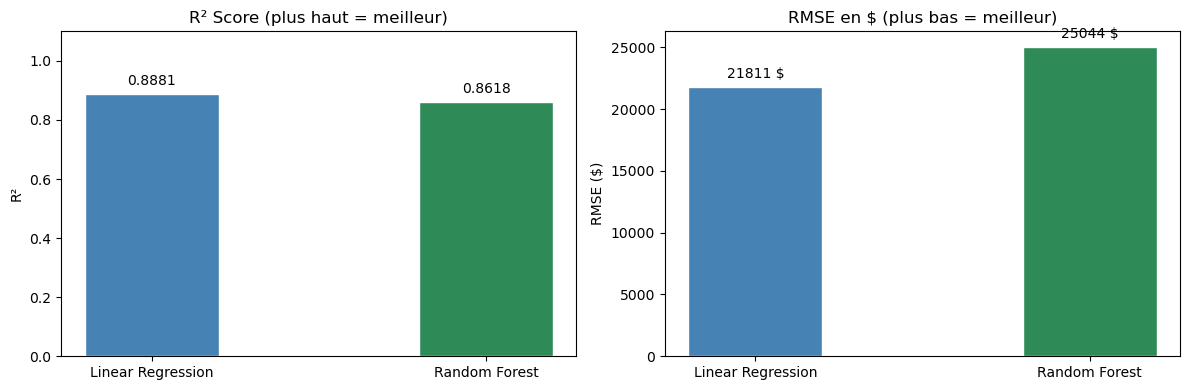

,R²,RMSE (log),RMSE ($)
Linear Regression,0.8881,0.1374,"21,811 $"
Random Forest,0.8618,0.1526,"25,044 $"


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

model_names = list(results.keys())
r2_scores   = [results[m]["R²"] for m in model_names]
rmse_scores = [results[m]["RMSE ($)"] for m in model_names]
colors      = ["steelblue", "seagreen"]

bars1 = axes[0].bar(model_names, r2_scores, color=colors, edgecolor="white", width=0.4)
axes[0].bar_label(bars1, fmt="%.4f", padding=4)
axes[0].set_ylim(0, 1.1)
axes[0].set_title("R² Score (plus haut = meilleur)")
axes[0].set_ylabel("R²")

bars2 = axes[1].bar(model_names, rmse_scores, color=colors, edgecolor="white", width=0.4)
axes[1].bar_label(bars2, fmt="%.0f $", padding=4)
axes[1].set_title("RMSE en $ (plus bas = meilleur)")
axes[1].set_ylabel("RMSE ($)")

plt.tight_layout()
plt.show()

results_df.style \
    .highlight_max(subset=["R²"], color="#c6f5c6") \
    .highlight_min(subset=["RMSE ($)", "RMSE (log)"], color="#c6f5c6") \
    .format({"R²": "{:.4f}", "RMSE (log)": "{:.4f}", "RMSE ($)": "{:,.0f} $"})

### 5.3 Analyse des résidus

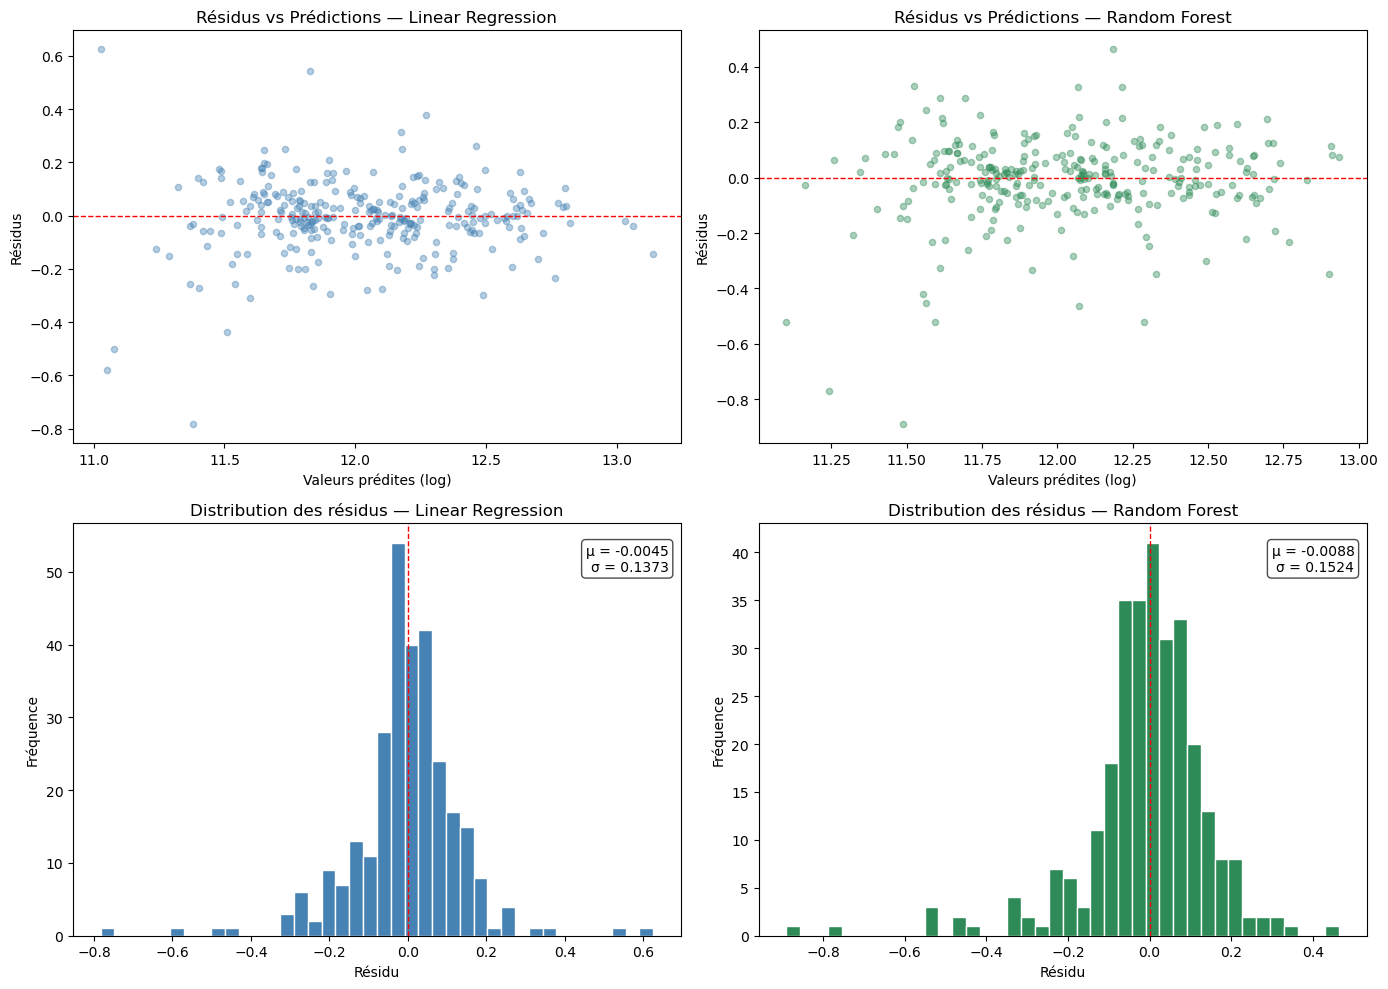

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_colors = {"Linear Regression": "steelblue", "Random Forest": "seagreen"}

for col, (name, model) in enumerate(models.items()):
    y_pred    = model.predict(X_test)
    residuals = y_test.values - y_pred
    color     = plot_colors[name]

    # Résidus vs valeurs prédites
    axes[0, col].scatter(y_pred, residuals, alpha=0.4, color=color, s=20)
    axes[0, col].axhline(0, color="red", linestyle="--", linewidth=1)
    axes[0, col].set_xlabel("Valeurs prédites (log)")
    axes[0, col].set_ylabel("Résidus")
    axes[0, col].set_title(f"Résidus vs Prédictions — {name}")

    # Distribution des résidus
    axes[1, col].hist(residuals, bins=40, color=color, edgecolor="white")
    axes[1, col].axvline(0, color="red", linestyle="--", linewidth=1)
    axes[1, col].set_xlabel("Résidu")
    axes[1, col].set_ylabel("Fréquence")
    axes[1, col].set_title(f"Distribution des résidus — {name}")
    mean_r = residuals.mean()
    std_r  = residuals.std()
    axes[1, col].text(0.98, 0.95, f"μ = {mean_r:.4f}\nσ = {std_r:.4f}",
                      transform=axes[1, col].transAxes, ha="right", va="top",
                      bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

plt.tight_layout()
plt.show()

## 6. Visualisations finales

### 6.1 Prix réels vs prix prédits

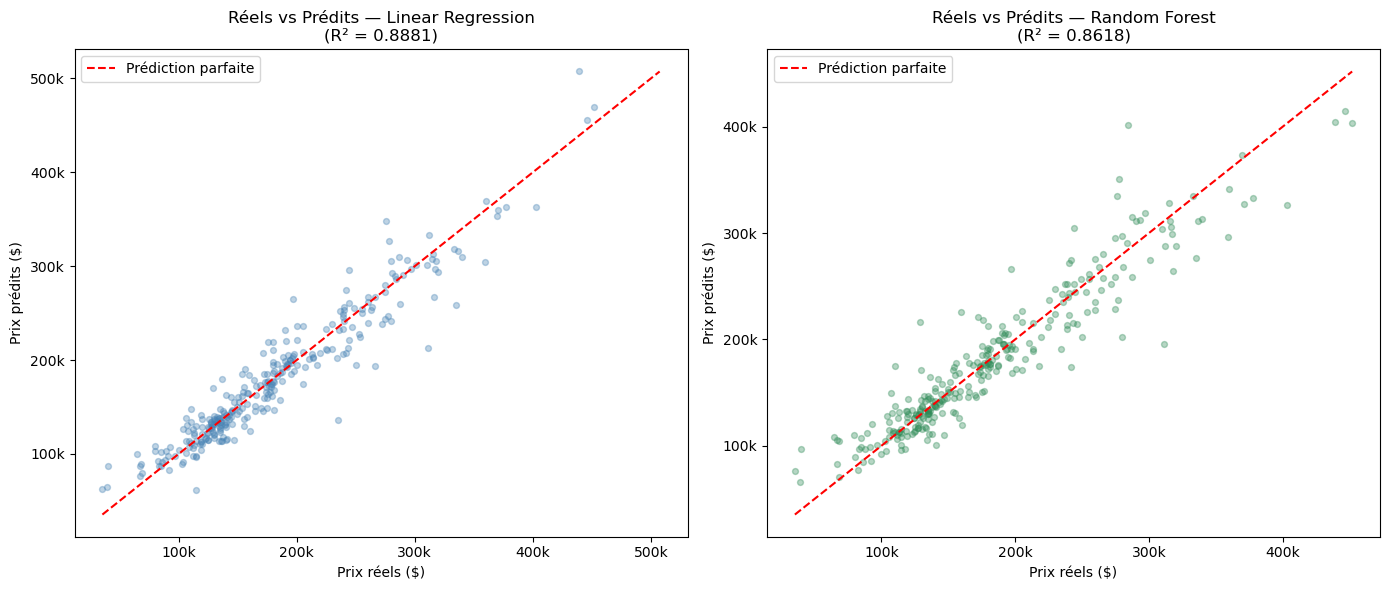

In [24]:
plot_colors = ["steelblue", "seagreen"]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for col, (name, model) in enumerate(models.items()):
    y_real = np.expm1(y_test.values)
    y_pred = np.expm1(model.predict(X_test))

    axes[col].scatter(y_real, y_pred, alpha=0.35, color=plot_colors[col], s=18)

    # Ligne de prédiction parfaite
    lim = [min(y_real.min(), y_pred.min()), max(y_real.max(), y_pred.max())]
    axes[col].plot(lim, lim, "r--", linewidth=1.5, label="Prédiction parfaite")

    r2 = r2_score(y_test.values, model.predict(X_test))
    axes[col].set_xlabel("Prix réels ($)")
    axes[col].set_ylabel("Prix prédits ($)")
    axes[col].set_title(f"Réels vs Prédits — {name}\n(R² = {r2:.4f})")
    axes[col].legend()
    axes[col].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
    axes[col].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

plt.tight_layout()
plt.show()

### 6.2 Importance des features — Random Forest

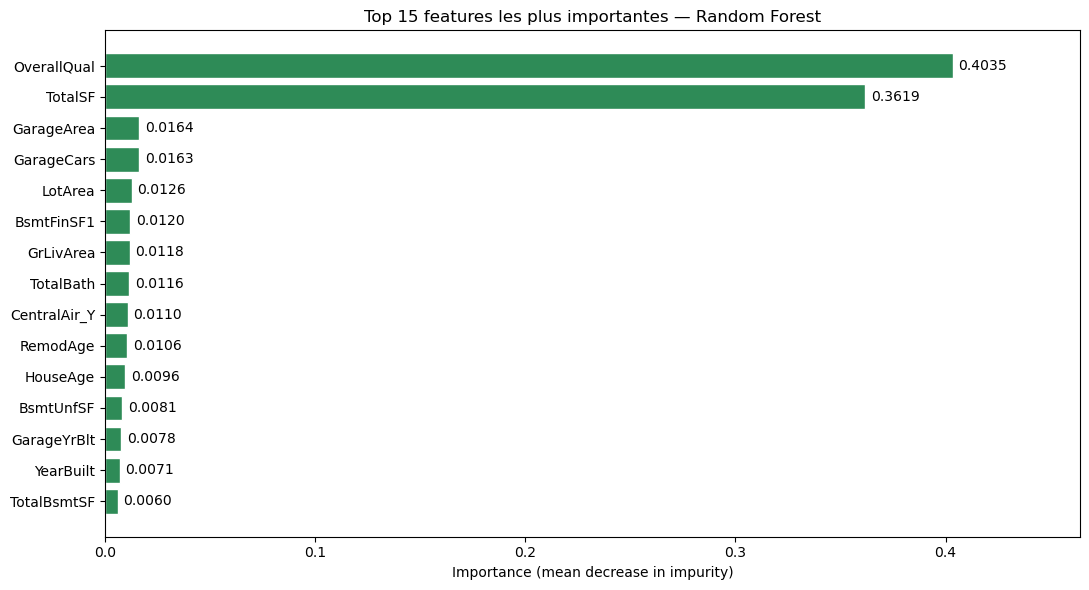

Top 5 features :
OverallQual    0.403480
TotalSF        0.361881
GarageArea     0.016374
GarageCars     0.016319
LotArea        0.012629

modèle rechargé : Pipeline  |  138 features


In [25]:
feature_imp = (
    pd.Series(rf.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(feature_imp.index[::-1], feature_imp.values[::-1], color="seagreen", edgecolor="white")
ax.bar_label(bars, fmt="%.4f", padding=4)
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_title("Top 15 features les plus importantes — Random Forest")
ax.set_xlim(0, feature_imp.max() * 1.15)
plt.tight_layout()
plt.show()

print("Top 5 features :")
print(feature_imp.head().to_string())

# Démonstration : comment recharger et utiliser le modèle sauvegardé
saved = joblib.load("../model.pkl")
print(f"\nmodèle rechargé : {type(saved['model']).__name__}  |  {len(saved['features'])} features")

### 6.3 Distribution des erreurs de prédiction

Linear Regression :
  Erreur médiane     : +686 $
  Erreur max         : 98,520 $
  Prédictions à ±10k : 50.0%
  Prédictions à ±20k : 73.6%

Random Forest :
  Erreur médiane     : -515 $
  Erreur max         : 117,621 $
  Prédictions à ±10k : 42.8%
  Prédictions à ±20k : 68.8%



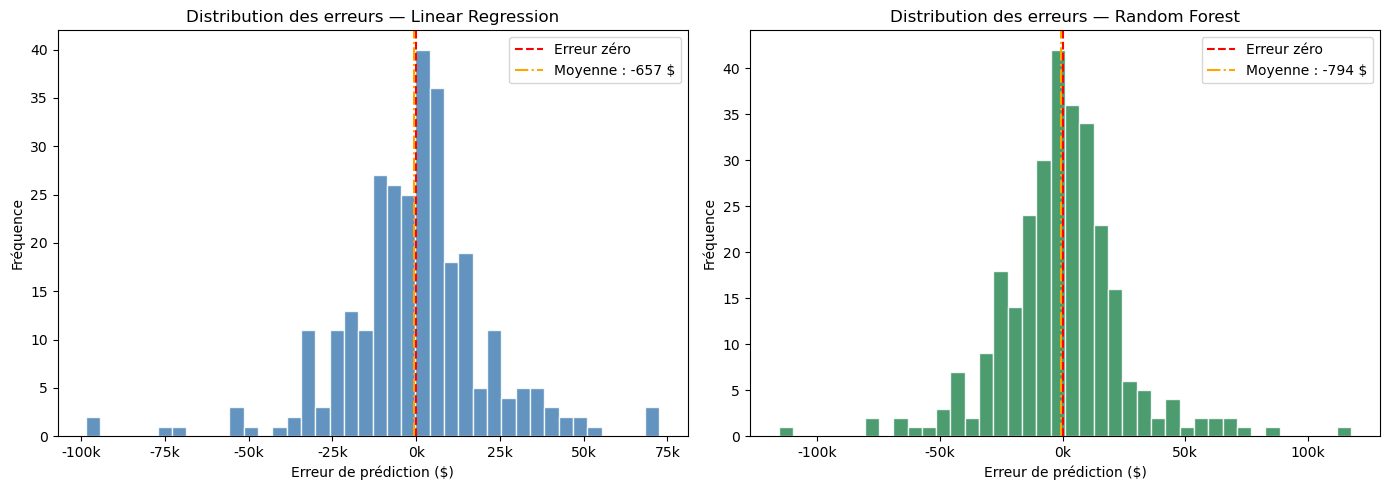

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col, (name, model) in enumerate(models.items()):
    y_real  = np.expm1(y_test.values)
    y_pred  = np.expm1(model.predict(X_test))
    errors  = y_pred - y_real
    color   = ["steelblue", "seagreen"][col]

    axes[col].hist(errors, bins=40, color=color, edgecolor="white", alpha=0.85)
    axes[col].axvline(0,            color="red",    linestyle="--", linewidth=1.5, label="Erreur zéro")
    axes[col].axvline(errors.mean(), color="orange", linestyle="-.", linewidth=1.5,
                      label=f"Moyenne : {errors.mean():+,.0f} $")
    axes[col].set_xlabel("Erreur de prédiction ($)")
    axes[col].set_ylabel("Fréquence")
    axes[col].set_title(f"Distribution des erreurs — {name}")
    axes[col].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
    axes[col].legend()

    pct_within_10k = (np.abs(errors) < 10_000).mean() * 100
    pct_within_20k = (np.abs(errors) < 20_000).mean() * 100
    print(f"{name} :")
    print(f"  Erreur médiane     : {np.median(errors):+,.0f} $")
    print(f"  Erreur max         : {np.abs(errors).max():,.0f} $")
    print(f"  Prédictions à ±10k : {pct_within_10k:.1f}%")
    print(f"  Prédictions à ±20k : {pct_within_20k:.1f}%\n")

plt.tight_layout()
plt.show()